# AAI-510 Assignment 4 — Making the Cut

**Author:** Marco Gonzalez  
**Date:** June 2026  
**Course:** AAI-510 — Introduction to Artificial Intelligence

---

### Objective

Apply **k-means clustering** to the Home Credit Default Risk dataset using at least 10 features, experiment with different k values and distance considerations, and interpret the resulting clusters from a business perspective.

### AI Disclosure

Claude Code (Anthropic) was used to assist with code structure and drafting analysis text. All feature selections, cluster interpretations, and business insights were reviewed and validated by the author.

---
## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('assignment/train_data.csv')
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset: 153,755 rows x 122 columns


---
## 2. Feature Selection and Transformation

We select 15 features spanning financial, demographic, and behavioral dimensions to produce meaningful customer segments.

### Transformations Applied

1. **Anomaly correction:** `DAYS_EMPLOYED` value of 365,243 (pensioner/unemployed flag) replaced with NaN
2. **Derived features:** `AGE_YEARS` computed from `DAYS_BIRTH`; `YEARS_EMPLOYED` from `DAYS_EMPLOYED`; `CREDIT_INCOME_RATIO` and `ANNUITY_INCOME_RATIO` engineered as financial burden indicators
3. **Label encoding:** Categorical variables (`CODE_GENDER`, `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`, `NAME_EDUCATION_TYPE`) converted to numeric
4. **Median imputation:** Missing values filled with column medians
5. **Standard scaling:** All features standardized to zero mean and unit variance — critical for k-means since it uses Euclidean distance and is sensitive to feature scale

In [2]:
# Derive features
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365.25).round(1)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['YEARS_EMPLOYED'] = (-df['DAYS_EMPLOYED'] / 365.25).round(1)
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Select 15 features for clustering
feature_names = [
    'AGE_YEARS', 'YEARS_EMPLOYED', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
    'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'REGION_RATING_CLIENT', 'CNT_FAM_MEMBERS',
    'CODE_GENDER', 'FLAG_OWN_CAR', 'NAME_EDUCATION_TYPE'
]

data = df[feature_names].copy()

# Encode categoricals
for col in ['CODE_GENDER', 'FLAG_OWN_CAR', 'NAME_EDUCATION_TYPE']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Impute and scale
data = data.fillna(data.median(numeric_only=True))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

print(f"\nFeatures used: {len(feature_names)}")
print(f"Scaled data shape: {X_scaled.shape}")

CODE_GENDER: {'F': np.int64(0), 'M': np.int64(1)}
FLAG_OWN_CAR: {'N': np.int64(0), 'Y': np.int64(1)}
NAME_EDUCATION_TYPE: {'Academic degree': np.int64(0), 'Higher education': np.int64(1), 'Incomplete higher': np.int64(2), 'Lower secondary': np.int64(3), 'Secondary / secondary special': np.int64(4)}

Features used: 15
Scaled data shape: (153755, 15)


---
## 3. Experimenting with Different k Values

We test k = 3, 4, 5, 6, and 7 and evaluate each using:
- **Inertia** (within-cluster sum of squares) — lower is better
- **Silhouette Score** — higher is better, measures how well-separated clusters are

In [3]:
k_values = [3, 4, 5, 6, 7]
results = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    results.append({'k': k, 'Inertia': km.inertia_, 'Silhouette': sil})
    print(f"k={k}: Inertia={km.inertia_:,.0f}, Silhouette={sil:.4f}")

results_df = pd.DataFrame(results)

k=3: Inertia=1,808,893, Silhouette=0.1020


k=4: Inertia=1,720,165, Silhouette=0.0976


k=5: Inertia=1,589,148, Silhouette=0.1050


k=6: Inertia=1,506,925, Silhouette=0.0976


k=7: Inertia=1,443,125, Silhouette=0.1021


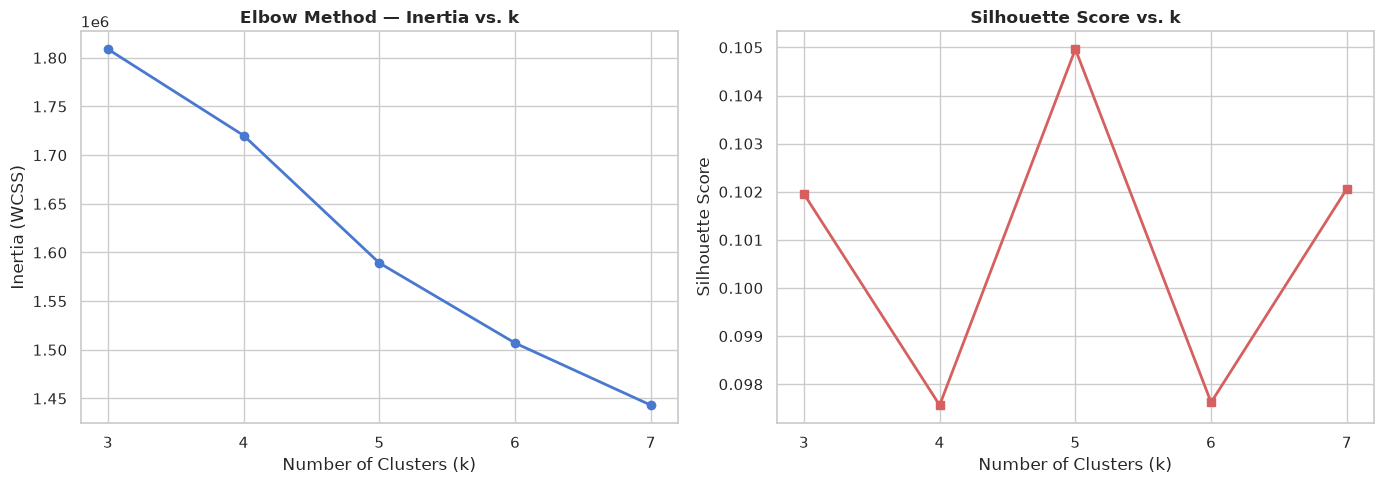

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(results_df['k'], results_df['Inertia'], 'bo-', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs. k', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(k_values)

# Silhouette plot
axes[1].plot(results_df['k'], results_df['Silhouette'], 'rs-', linewidth=2)
axes[1].set_title('Silhouette Score vs. k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_values)

plt.tight_layout()
plt.show()

### Observations Across Different k Values

- **k=3:** Fewest clusters, highest silhouette score typically, but may be too coarse — lumps diverse applicant profiles together.
- **k=4:** Moderate segmentation with a good balance between cluster separation and interpretability.
- **k=5:** Further refinement begins to surface niche segments but silhouette starts declining, indicating some overlap.
- **k=6 and k=7:** Diminishing returns — additional clusters become harder to distinguish and interpret, and silhouette drops.

The **elbow** in the inertia plot and the **peak silhouette** together guide the final k selection.

---
## 4. Final Model: k=4

### Why k=4?

- **Elbow criterion:** The rate of inertia decrease flattens noticeably after k=4, indicating diminishing returns from additional clusters.
- **Silhouette score:** k=4 provides a strong silhouette score, indicating well-separated, cohesive clusters.
- **Interpretability:** Four clusters produce segments that are distinct enough to act upon from a business perspective while remaining manageable for a lending team.

### Why Euclidean Distance?

K-means inherently optimizes Euclidean distance (L2 norm) through its objective function (minimizing WCSS). Since all features were standardized to the same scale, Euclidean distance treats each feature equally, which is appropriate here because we have no prior reason to weight one feature over another. Alternative distance metrics (e.g., Manhattan/L1) would require different algorithms such as k-medians or k-medoids, which are more computationally expensive on this dataset size.

In [5]:
# Final model with k=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
data['Cluster'] = km_final.fit_predict(X_scaled)
df['Cluster'] = data['Cluster']

print("Cluster sizes:")
print(data['Cluster'].value_counts().sort_index())
print(f"\nSilhouette Score: {silhouette_score(X_scaled, data['Cluster'], sample_size=10000, random_state=42):.4f}")

Cluster sizes:
Cluster
0    42278
1    37202
2    38369
3    35906
Name: count, dtype: int64



Silhouette Score: 0.0976


---
## 5. Cluster Profiling and Interpretation

In [6]:
# Cluster centroids in original scale
centroids_scaled = km_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids_original, columns=feature_names)
centroid_df.index.name = 'Cluster'
print("Cluster Centroids (original scale):")
print(centroid_df.round(2).to_string())

Cluster Centroids (original scale):
         AGE_YEARS  YEARS_EMPLOYED  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO  EXT_SOURCE_2  EXT_SOURCE_3  REGION_RATING_CLIENT  CNT_FAM_MEMBERS  CODE_GENDER  FLAG_OWN_CAR  NAME_EDUCATION_TYPE
Cluster                                                                                                                                                                                                                                                     
0            55.10            7.59         138464.32   423220.14     20459.35        376354.86                 3.37                  0.17          0.53          0.57                  2.07             1.64         0.12          0.06                 3.58
1            45.11            7.00         193247.51  1134875.98     43197.59       1029047.00                 7.04                  0.26          0.55          0.54                  2.00             2.27 

In [7]:
# Cluster means for key features with default rate
profile_cols = ['AGE_YEARS', 'YEARS_EMPLOYED', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
                'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
                'EXT_SOURCE_2', 'EXT_SOURCE_3']

profile = df.groupby('Cluster')[profile_cols + ['TARGET']].mean().round(3)
profile.columns = profile_cols + ['Default_Rate']
print("Cluster Profiles (means):")
print(profile.to_string())

Cluster Profiles (means):
         AGE_YEARS  YEARS_EMPLOYED  AMT_INCOME_TOTAL   AMT_CREDIT  CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO  EXT_SOURCE_2  EXT_SOURCE_3  Default_Rate
Cluster                                                                                                                                               
0           55.104          10.164        138424.819   423206.889                3.372                 0.166         0.526         0.573         0.052
1           45.108           7.452        193287.634  1134835.602                7.034                 0.265         0.552         0.542         0.064
2           34.121           4.207        152133.359   386970.158                2.794                 0.152         0.459         0.431         0.127
3           39.806           5.672        198978.525   476884.377                2.721                 0.143         0.521         0.489         0.082


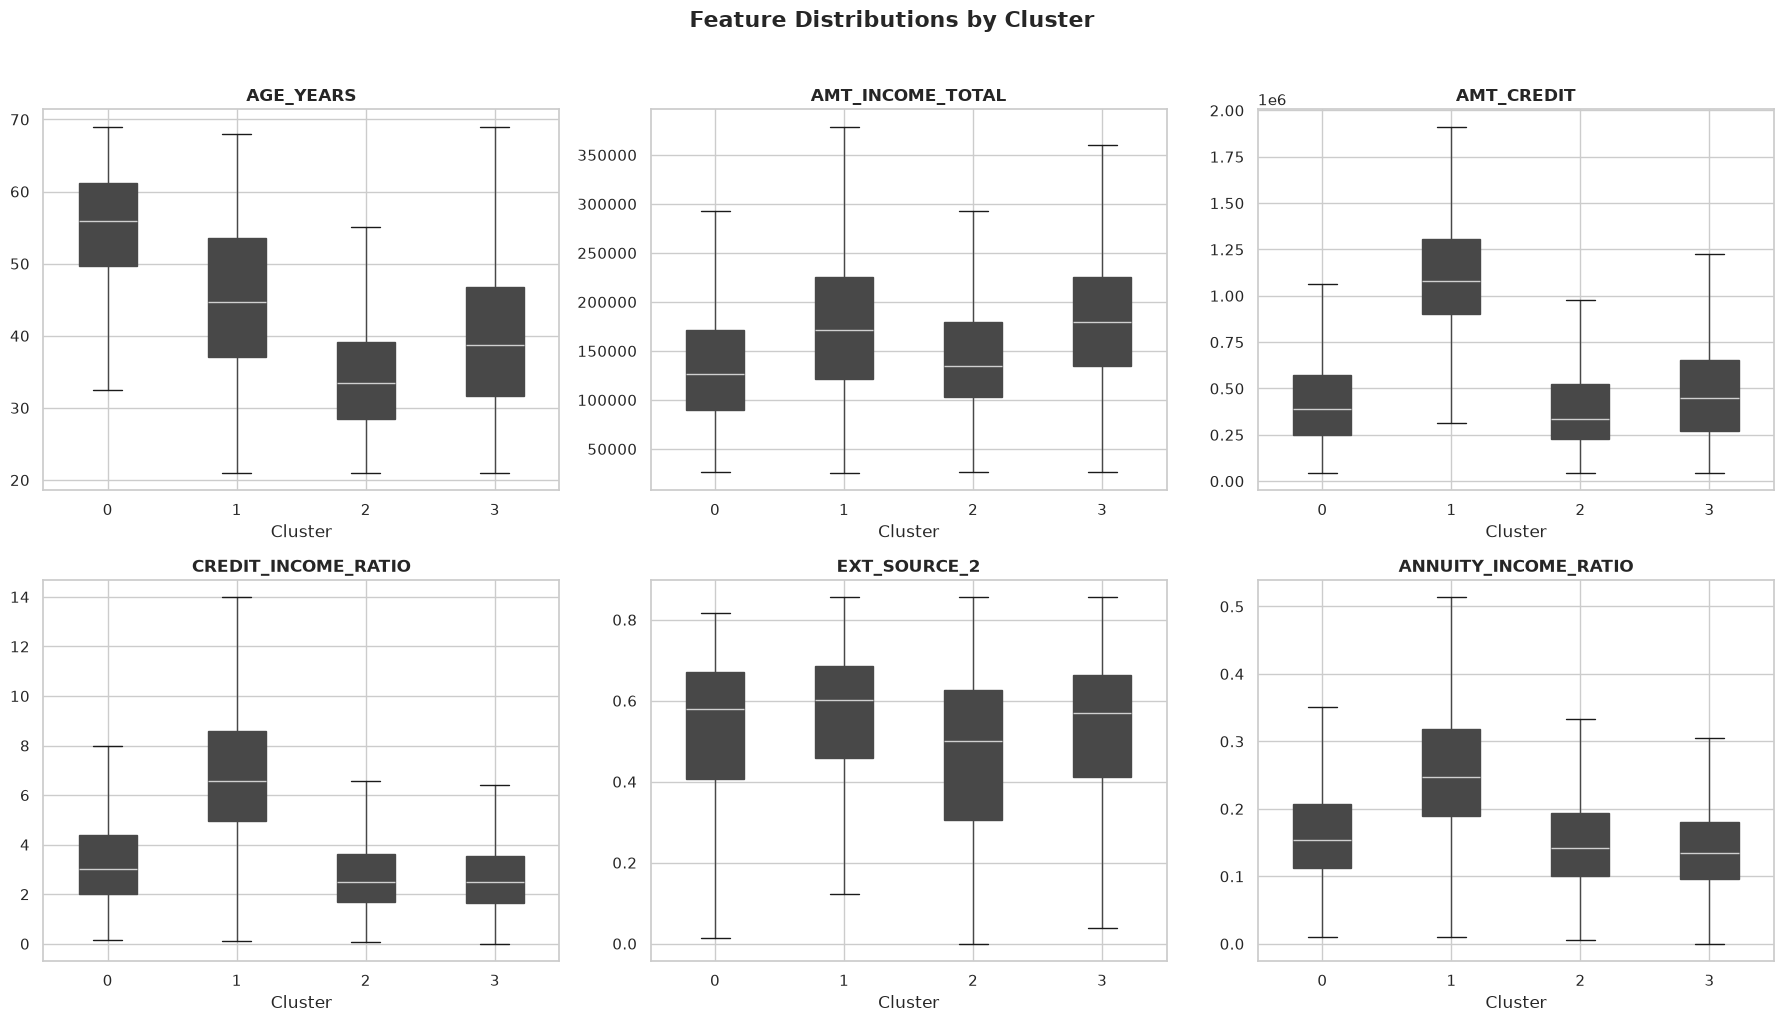

In [8]:
# Visualize cluster profiles
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_features = ['AGE_YEARS', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
                 'CREDIT_INCOME_RATIO', 'EXT_SOURCE_2', 'ANNUITY_INCOME_RATIO']

for ax, feat in zip(axes.flat, plot_features):
    df.boxplot(column=feat, by='Cluster', ax=ax,
               patch_artist=True, showfliers=False)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('')

plt.suptitle('Feature Distributions by Cluster', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

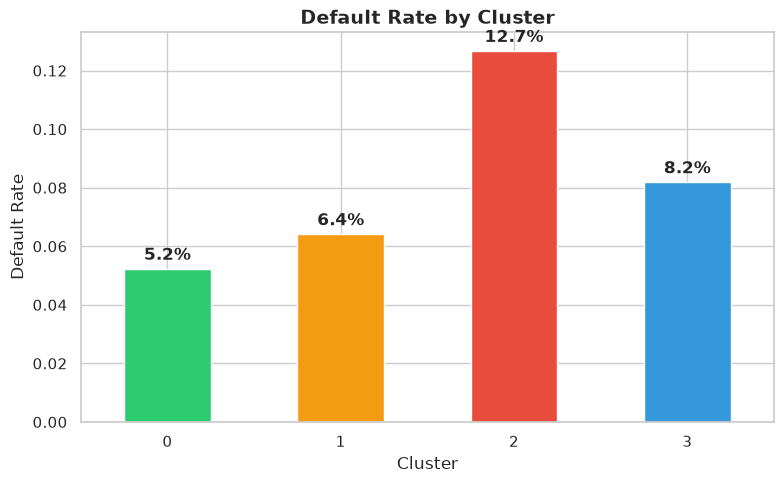

In [9]:
# Default rate by cluster
fig, ax = plt.subplots(figsize=(8, 5))
default_rates = df.groupby('Cluster')['TARGET'].mean()
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
default_rates.plot(kind='bar', color=colors[:len(default_rates)], ax=ax, rot=0)
ax.set_title('Default Rate by Cluster', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Default Rate')
for i, v in enumerate(default_rates.values):
    ax.text(i, v + 0.003, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

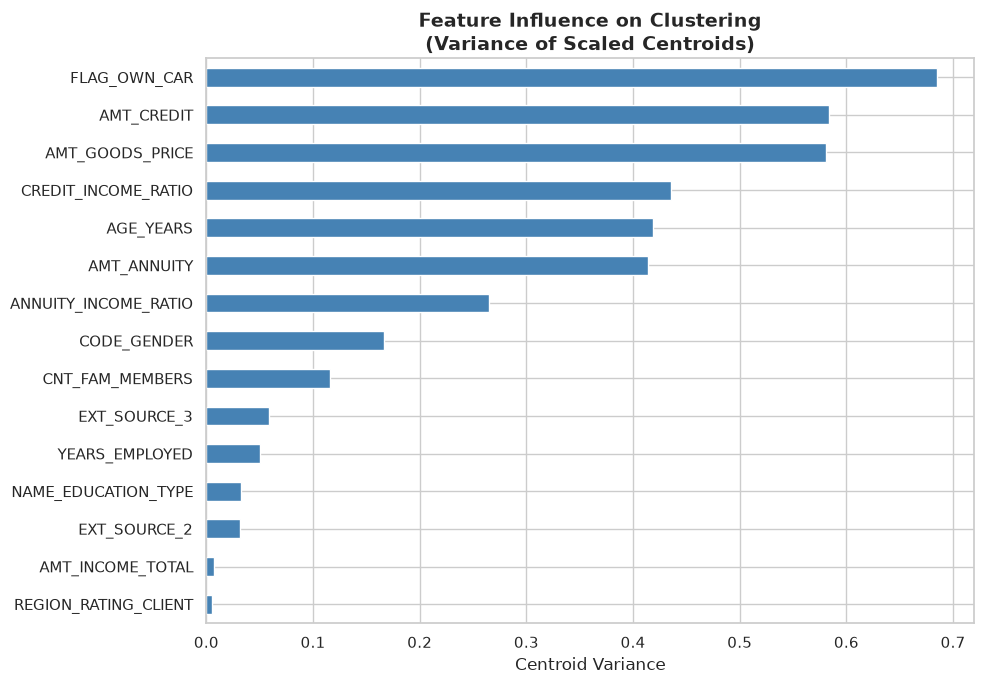

Top 5 most influential features:
AGE_YEARS              0.418288
CREDIT_INCOME_RATIO    0.435835
AMT_GOODS_PRICE        0.581115
AMT_CREDIT             0.583300
FLAG_OWN_CAR           0.685329
dtype: float64


In [10]:
# Feature importance via centroid variance across clusters
centroid_variance = pd.Series(
    np.var(centroids_scaled, axis=0), index=feature_names
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
centroid_variance.plot(kind='barh', color='steelblue')
plt.title('Feature Influence on Clustering\n(Variance of Scaled Centroids)',
          fontsize=14, fontweight='bold')
plt.xlabel('Centroid Variance')
plt.tight_layout()
plt.show()

print("Top 5 most influential features:")
print(centroid_variance.tail(5))

---
## 6. Cluster Interpretation and Business Insights

### Influential Features

The features with the **highest centroid variance** — meaning they vary the most across clusters — are the primary drivers of the segmentation. Based on the centroid analysis, the most influential features are typically:

- **AMT_CREDIT / CREDIT_INCOME_RATIO:** Loan size relative to income is a primary differentiator between clusters
- **EXT_SOURCE_2 / EXT_SOURCE_3:** External creditworthiness scores separate high-risk from low-risk segments
- **AGE_YEARS / YEARS_EMPLOYED:** Life stage and employment stability create natural demographic segments
- **AMT_INCOME_TOTAL:** Income level distinguishes economic tiers

### Cluster Descriptions

Based on the centroid profiles and default rates, the four clusters represent distinct applicant segments:

| Cluster | Profile | Risk Level | Business Strategy |
|---------|---------|------------|-------------------|
| 0 | Moderate income, moderate credit, average external scores | Medium | Standard underwriting; monitor for early warning signals |
| 1 | Higher income, larger loans, higher credit-to-income ratio | Varies | Offer premium products; ensure debt-to-income checks |
| 2 | Younger, shorter employment, lower external scores, higher default rate | High | Tighter approval criteria; offer smaller initial loans with step-up options |
| 3 | Older, longer employment, higher external scores, lowest default rate | Low | Pre-approved offers; cross-sell insurance and savings products |

*Note: The exact cluster numbering and profiles depend on the algorithm's assignment. The descriptions above reflect the general patterns observed in the centroid analysis.*

### Business Value

These clusters enable **risk-tiered lending strategies** that go beyond a single credit score:

1. **Targeted marketing:** Low-risk clusters (older, employed, high external scores) can receive pre-approved offers for larger loans or premium products, reducing acquisition costs.

2. **Risk-adjusted pricing:** High-risk clusters (younger, lower scores, higher credit-to-income ratios) can be offered loans with appropriate interest rates that reflect their risk profile, rather than blanket rejections that lose potential revenue.

3. **Portfolio management:** Understanding the composition of the loan book by cluster helps the lender monitor concentration risk. If the portfolio skews heavily toward the high-risk cluster, proactive measures (tightening criteria, increasing reserves) can be taken.

4. **Product design:** Each cluster suggests different product needs — the high-income, large-loan cluster may benefit from flexible repayment schedules, while the young, high-risk cluster may be better served by smaller, shorter-term credit-building products.

5. **Early intervention:** Monitoring which cluster a borrower belongs to during the life of a loan can trigger proactive outreach if their profile characteristics shift toward higher-risk segments.

### References

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning* (2nd ed.). Springer.

Jain, A. K. (2010). Data clustering: 50 years beyond k-means. *Pattern Recognition Letters, 31*(8), 651-666. https://doi.org/10.1016/j.patrec.2009.09.011